In [ ]:
import numpy as np
import glob
import os

# ============================================================
# User settings
# ============================================================

rdf_pattern = "rdf_300K_quench_sample*.txt"
cn_pattern  = "cn_frames_quench_sample*.lammpstrj"
rho_pattern = "density_300K_quench_sample*.txt"

TYPE_AL = 1
TYPE_O  = 2

cn_max = 10
frame_stride = 1   # use all frames

# ============================================================
# -------- RDF PART (ensemble average only)
# ============================================================

def read_rdf_fix_file(path):
    with open(path) as f:
        lines = [l.strip() for l in f if l.strip() and not l.startswith("#")]

    nbin = int(lines[0].split()[1])
    data = np.array([[float(x) for x in l.split()] for l in lines[1:1+nbin]])

    r   = data[:,1]
    gAA = data[:,2]
    gAO = data[:,4]
    gOO = data[:,6]
    return r, gAA, gAO, gOO


def ensemble_avg_rdf(files):
    r0 = None
    gAA, gAO, gOO = [], [], []

    for f in files:
        r, a, b, c = read_rdf_fix_file(f)
        if r0 is None:
            r0 = r
        gAA.append(a)
        gAO.append(b)
        gOO.append(c)

    return (
        r0,
        np.mean(gAA, axis=0),
        np.mean(gAO, axis=0),
        np.mean(gOO, axis=0)
    )

def iter_lammpstrj(path):
    with open(path) as f:
        while True:
            line = f.readline()
            if not line:
                break

            if not line.startswith("ITEM: TIMESTEP"):
                continue

            f.readline()  # timestep

            f.readline()  # ITEM: NUMBER OF ATOMS
            n = int(f.readline())

            f.readline()  # ITEM: BOX BOUNDS ...
            box = np.array(
                [list(map(float, f.readline().split())) for _ in range(3)]
            )
            L = box[:, 1] - box[:, 0]

            f.readline()  # ITEM: ATOMS ...
            pos = np.zeros((n, 3))
            typ = np.zeros(n, dtype=int)

            for i in range(n):
                parts = f.readline().split()
                typ[i] = int(parts[1])
                pos[i] = [float(parts[2]), float(parts[3]), float(parts[4])]

            yield typ, pos, L


# ============================================================
# -------- CN PART
# ============================================================

def compute_cn_hist(path, r_cut):
    from scipy.spatial import cKDTree

    hist = np.zeros(cn_max+1)
    frames = 0

    for types, pos, L in iter_lammpstrj(path):
        frames += 1
        # --- wrap positions into [0, L) ---
        pos_wrapped = pos % L

        al = pos_wrapped[types == TYPE_AL]
        o  = pos_wrapped[types == TYPE_O]

        tree = cKDTree(o, boxsize=L)
        cn = [len(x) for x in tree.query_ball_point(al, r_cut)]


        cn = np.clip(cn, 0, cn_max)
        hist += np.bincount(cn, minlength=cn_max+1)

    prob = hist / hist.sum()
    mean_cn = np.sum(np.arange(cn_max+1) * prob)

    return prob, mean_cn

# ============================================================
# -------- Density PART
# ============================================================

def read_density_file(path):
    data = []
    with open(path) as f:
        for l in f:
            if l.strip() and not l.startswith("#"):
                data.append(float(l.split()[-1]))
    return np.mean(data)

# ============================================================
# =================== MAIN ===================
# ============================================================

rdf_files = sorted(glob.glob(rdf_pattern))
cn_files  = sorted(glob.glob(cn_pattern))
rho_files = sorted(glob.glob(rho_pattern))

# ---------- RDF ----------
r, gAA, gAO, gOO = ensemble_avg_rdf(rdf_files)
np.savetxt(
    "rdf_ensemble_avg.csv",
    np.column_stack([r, gAA, gAO, gOO]),
    header="r_A g_AlAl g_AlO g_OO",
    comments=""
)

# ---------- r_cut from Al-O RDF ----------
i_peak = np.argmax(gAO)
r_cut = r[i_peak + np.argmin(gAO[i_peak:])]

# ---------- CN ----------
probs, mean_cns = [], []

for f in cn_files:
    p, m = compute_cn_hist(f, r_cut)
    probs.append(p)
    mean_cns.append(m)

probs = np.array(probs)
mean_prob = probs.mean(axis=0)
se_prob   = probs.std(axis=0, ddof=1) / np.sqrt(len(probs))

mean_cn = np.mean(mean_cns)
se_cn   = np.std(mean_cns, ddof=1) / np.sqrt(len(mean_cns))

np.savetxt(
    "cn_AlO_distribution_with_error.csv",
    np.column_stack([np.arange(cn_max+1), mean_prob, se_prob]),
    header="CN prob_mean prob_se",
    comments=""
)

with open("cn_AlO_summary.txt", "w") as f:
    f.write(f"r_cut = {r_cut:.4f} Å\n")
    f.write(f"<CN> = {mean_cn:.4f} ± {se_cn:.4f}\n")

# ---------- Density ----------
rho_samples = [read_density_file(f) for f in rho_files]
rho_mean = np.mean(rho_samples)
rho_se   = np.std(rho_samples, ddof=1) / np.sqrt(len(rho_samples))

with open("density_300K_summary.txt", "w") as f:
    f.write(f"density = {rho_mean:.4f} ± {rho_se:.4f} g/cm^3\n")

print("Analysis complete.")


Analysis complete.


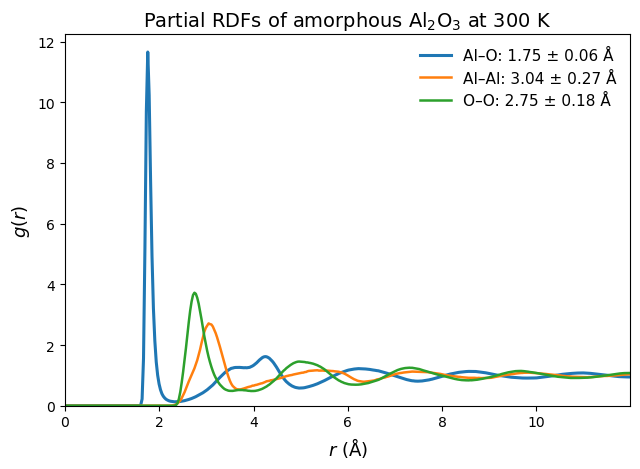

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Load RDF data
# =========================
rdf = np.loadtxt("rdf_ensemble_avg.csv", skiprows=1)
r   = rdf[:,0]
gAA = rdf[:,1]
gAO = rdf[:,2]
gOO = rdf[:,3]

# =========================
# Peak + HWHM finder
# =========================
def peak_and_hwhm(r, g, r_max):
    """
    Return (r_peak, HWHM_left) for the first peak below r_max.
    HWHM is defined using the left half-maximum crossing.
    """
    mask = r < r_max
    r_sub = r[mask]
    g_sub = g[mask]

    # peak index
    i_peak = np.argmax(g_sub)
    r_peak = r_sub[i_peak]
    g_peak = g_sub[i_peak]
    half   = 0.5 * g_peak

    # search left side for half-maximum crossing
    for i in range(i_peak-1, 0, -1):
        if g_sub[i] <= half:
            # linear interpolation
            r1, r2 = r_sub[i], r_sub[i+1]
            g1, g2 = g_sub[i], g_sub[i+1]
            r_half = r1 + (half - g1) * (r2 - r1) / (g2 - g1)
            hwhm = r_peak - r_half
            return r_peak, hwhm

    return r_peak, None

# =========================
# Compute peaks + HWHM
# =========================
r_AO, h_AO = peak_and_hwhm(r, gAO, r_max=2.5)
r_OO, h_OO = peak_and_hwhm(r, gOO, r_max=3.2)
r_AA, h_AA = peak_and_hwhm(r, gAA, r_max=3.8)

# =========================
# Plot RDF (no HWHM shown)
# =========================
plt.figure(figsize=(6.5, 4.8))

plt.plot(r, gAO, lw=2.2,
         label=f"Al–O: {r_AO:.2f} ± {h_AO:.2f} Å")
plt.plot(r, gAA, lw=1.8,
         label=f"Al–Al: {r_AA:.2f} ± {h_AA:.2f} Å")
plt.plot(r, gOO, lw=1.8,
         label=f"O–O: {r_OO:.2f} ± {h_OO:.2f} Å")

plt.xlabel(r"$r$ (Å)", fontsize=13)
plt.ylabel(r"$g(r)$", fontsize=13)
plt.xlim(0, r.max())
plt.ylim(bottom=0)

plt.legend(frameon=False, fontsize=11)
plt.title(
    "Partial RDFs of amorphous Al$_2$O$_3$ at 300 K",
    fontsize=14
)
plt.tight_layout()
plt.savefig("rdf_amorphous_300K.png", dpi=300)
plt.show()

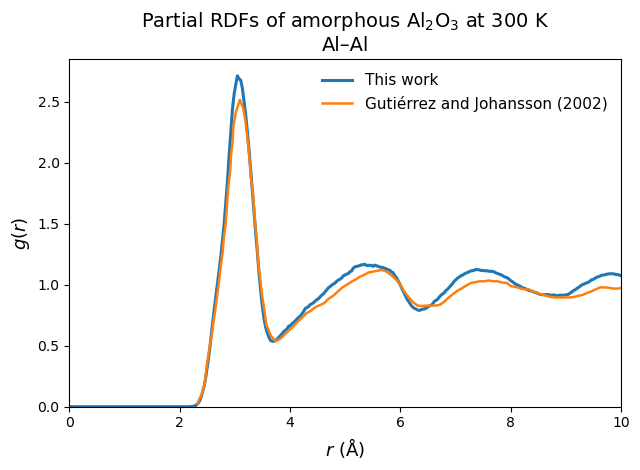

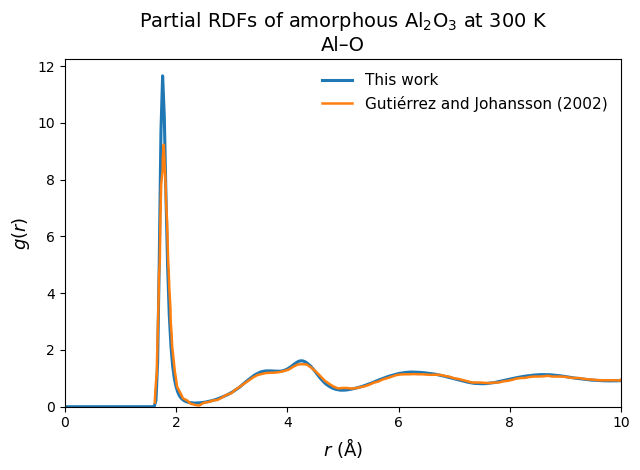

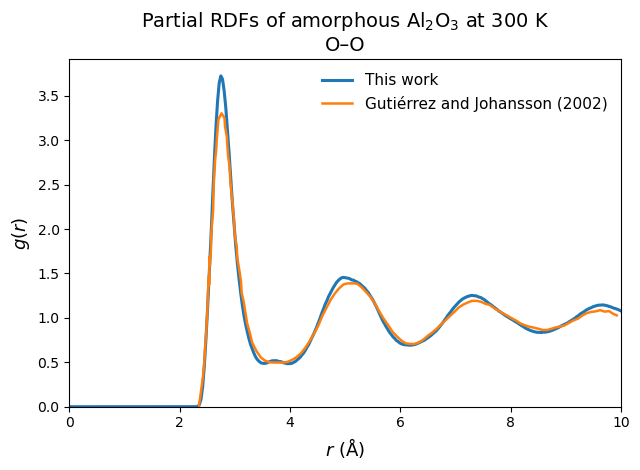

Saved: rdf_compare_Al-Al.png, rdf_compare_Al-O.png, rdf_compare_O-O.png


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# File names
# ============================================================
OUR_FILE = "rdf_ensemble_avg.csv"

EXP_FILES = {
    "Al–Al": "ALAL_clean.csv",
    "Al–O":  "ALO_clean.csv",
    "O–O":   "OO_clean.csv",
}

# ============================================================
# Load our RDF data
# Assumed columns: r, gAA, gAO, gOO
# ============================================================
def load_our_rdf(path):
    try:
        data = np.loadtxt(path, skiprows=1)  # whitespace separated
    except Exception:
        data = np.loadtxt(path, delimiter=",", skiprows=1)  # comma separated
    return data[:, 0], data[:, 1], data[:, 2], data[:, 3]

# ============================================================
# Load literature RDF data
# Assumed columns: r, g(r), with header
# ============================================================
def load_two_col(path):
    data = np.loadtxt(path, delimiter=",", skiprows=1)
    return data[:, 0], data[:, 1]

# ============================================================
# Read data
# ============================================================
r, gAA, gAO, gOO = load_our_rdf(OUR_FILE)

our_curves = {
    "Al–Al": (r, gAA),
    "Al–O":  (r, gAO),
    "O–O":   (r, gOO),
}

# ============================================================
# Plot settings
# ============================================================
TITLE_BASE = "Partial RDFs of amorphous Al$_2$O$_3$ at 300 K"
DPI = 300
XMAX = 10

# ============================================================
# Plot and save figures
# ============================================================
for pair_name, exp_path in EXP_FILES.items():
    r_our, g_our = our_curves[pair_name]
    r_exp, g_exp = load_two_col(exp_path)

    plt.figure(figsize=(6.5, 4.8))
    plt.plot(r_our, g_our, lw=2.2, label="This work")
    plt.plot(r_exp, g_exp, lw=1.8, label="Gutiérrez and Johansson (2002)")

    plt.xlabel(r"$r$ (Å)", fontsize=13)
    plt.ylabel(r"$g(r)$", fontsize=13)
    plt.xlim(0, XMAX)
    plt.ylim(bottom=0)

    plt.title(f"{TITLE_BASE}\n{pair_name}", fontsize=14)
    plt.legend(frameon=False, fontsize=11)

    plt.tight_layout()

    safe_name = pair_name.replace("–", "-").replace(" ", "")
    out_name = f"rdf_compare_{safe_name}.png"
    plt.savefig(out_name, dpi=DPI)
    plt.show()

print("Saved: rdf_compare_Al-Al.png, rdf_compare_Al-O.png, rdf_compare_O-O.png")

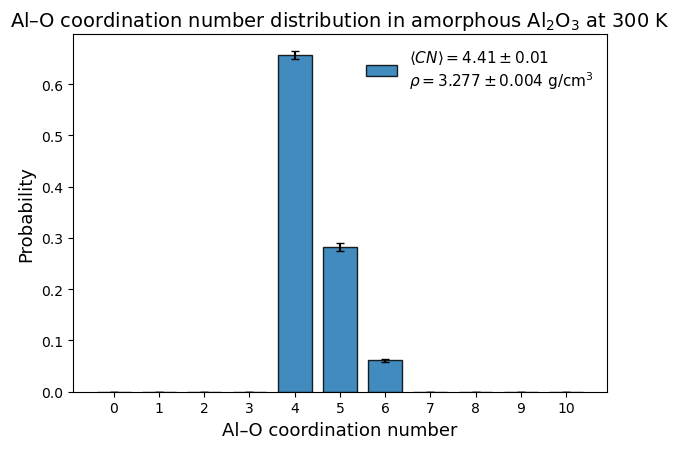

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Load CN distribution
# =========================
cn_data = np.loadtxt("cn_AlO_distribution_with_error.csv", skiprows=1)

cn_vals = cn_data[:,0]
prob    = cn_data[:,1]
err     = cn_data[:,2]

# Reported values
mean_cn = 4.4051
se_cn   = 0.0084
rho     = 3.2771
se_rho  = 0.0042

# =========================
# Plot CN histogram
# =========================
plt.figure(figsize=(6.2, 4.6))

plt.bar(
    cn_vals, prob, width=0.75,
    yerr=err, capsize=3,
    edgecolor="k", alpha=0.85
)

plt.xlabel("Al–O coordination number", fontsize=13)
plt.ylabel("Probability", fontsize=13)

plt.xticks(cn_vals)

# Legend text (key requirement)
legend_text = (
    rf"$\langle CN \rangle = {mean_cn:.2f} \pm {se_cn:.2f}$" + "\n"
    rf"$\rho = {rho:.3f} \pm {se_rho:.3f}$ g/cm$^3$"
)

plt.legend([legend_text], frameon=False, fontsize=11, loc="upper right")
plt.title(
    "Al–O coordination number distribution in amorphous Al$_2$O$_3$ at 300 K",
    fontsize=14
)

plt.tight_layout()
plt.savefig("cn_distribution_amorphous_300K.png", dpi=300)
plt.show()


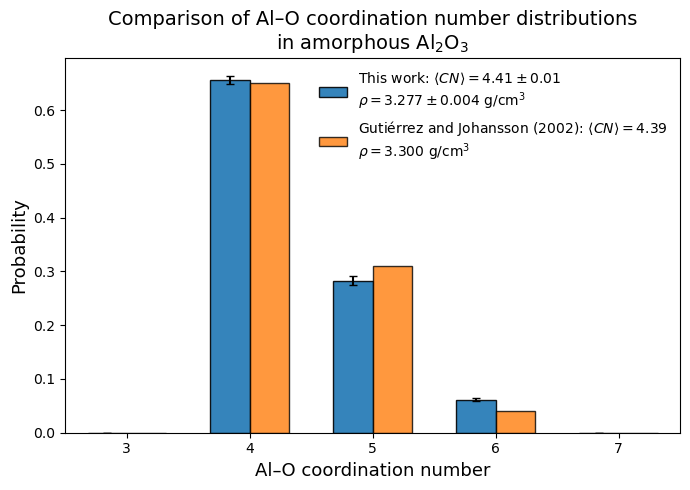

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Load THIS WORK CN distribution
# file columns: CN, probability, error
# =========================
cn_data = np.loadtxt("cn_AlO_distribution_with_error.csv", skiprows=1)

cn_vals = cn_data[:, 0].astype(int)
prob_my = cn_data[:, 1]
err_my  = cn_data[:, 2]

# =========================
# Literature data: density = 3.3 g/cm^3
# Gutiérrez and Johansson (2002)
# Al-centered Al-O coordination distribution
# =========================
cn_all = np.arange(0, 11, 1)

prob_lit = np.zeros_like(cn_all, dtype=float)
prob_lit[4] = 0.65
prob_lit[5] = 0.31
prob_lit[6] = 0.04

# =========================
# Put THIS WORK onto the same CN axis
# =========================
prob_my_full = np.zeros_like(cn_all, dtype=float)
err_my_full  = np.zeros_like(cn_all, dtype=float)

for cn, p, e in zip(cn_vals, prob_my, err_my):
    if 0 <= cn <= 10:
        prob_my_full[cn] = p
        err_my_full[cn]  = e

# =========================
# Mean CN values
# =========================
mean_my  = np.sum(cn_all * prob_my_full)
mean_lit = np.sum(cn_all * prob_lit)

rho_my    = 3.2771
se_rho_my = 0.0042
se_cn_my  = 0.0084

rho_lit = 3.300

# =========================
# Plot grouped bar chart
# =========================
plt.figure(figsize=(7.0, 5.0))

width = 0.32
x = cn_all

plt.bar(
    x - width/2, prob_my_full, width=width,
    yerr=err_my_full, capsize=3,
    edgecolor="k", alpha=0.90,
    label=(
        rf"This work: $\langle CN \rangle = {mean_my:.2f} \pm {se_cn_my:.2f}$" + "\n"
        rf"$\rho = {rho_my:.3f} \pm {se_rho_my:.3f}$ g/cm$^3$"
    )
)

plt.bar(
    x + width/2, prob_lit, width=width,
    edgecolor="k", alpha=0.80,
    label=(
        rf"Gutiérrez and Johansson (2002): $\langle CN \rangle = {mean_lit:.2f}$" + "\n"
        rf"$\rho = {rho_lit:.3f}$ g/cm$^3$"
    )
)

plt.xlabel("Al–O coordination number", fontsize=13)
plt.ylabel("Probability", fontsize=13)
plt.xticks(cn_all)
plt.xlim(2.5, 7.5)   # focus on the meaningful CN range
plt.ylim(bottom=0)

plt.title(
    "Comparison of Al–O coordination number distributions\nin amorphous Al$_2$O$_3$",
    fontsize=14
)

plt.legend(frameon=False, fontsize=10, loc="upper right")
plt.tight_layout()
plt.savefig("cn_distribution_compare_33.png", dpi=300)
plt.show()

In [5]:
import numpy as np
import re

# ============================
# User settings
# ============================
n_samples = 10
n_atoms = 1000
log_template = "log_quench_sample{}.txt"

# how many last Eq steps to average (e.g. last 20 ps)
# thermo = 1000 steps → 20 ps = 20000 steps → 20 points
N_LAST = 20

# ============================
# Parser
# ============================
def extract_eq_toteng(logfile):
    """
    Extract TotEng values from Section B (300 K equilibration).
    Section B is identified as the SECOND occurrence of:
        'Step Temp Press Volume Density PotEng TotEng'
    """
    with open(logfile, "r") as f:
        lines = f.readlines()

    header_indices = [
        i for i, l in enumerate(lines)
        if re.match(r"\s*Step\s+Temp\s+Press\s+Volume\s+Density\s+PotEng\s+TotEng", l)
    ]

    if len(header_indices) < 2:
        raise RuntimeError(f"{logfile}: cannot find Section B header")

    # Section B starts after the second header
    start = header_indices[1] + 1

    toteng = []
    for l in lines[start:]:
        if l.strip().startswith("Loop time"):
            break
        parts = l.split()
        if len(parts) == 7:
            toteng.append(float(parts[6]))  # TotEng column

    if len(toteng) < N_LAST:
        raise RuntimeError(f"{logfile}: not enough Eq data points")

    return np.mean(toteng[-N_LAST:])


# ============================
# Main
# ============================
per_atom_energy = []

for i in range(1, n_samples + 1):
    logfile = log_template.format(i)
    avg_toteng = extract_eq_toteng(logfile)
    e_atom = avg_toteng / n_atoms
    per_atom_energy.append(e_atom)
    print(f"sample {i:2d}: {e_atom:.6f} eV/atom")

per_atom_energy = np.array(per_atom_energy)

print("\nEnsemble average (Section B, TotEng):")
print(f"{per_atom_energy.mean():.6f} ± {per_atom_energy.std(ddof=1):.6f} eV/atom")

sample  1: -8.693593 eV/atom
sample  2: -8.694769 eV/atom
sample  3: -8.692029 eV/atom
sample  4: -8.696361 eV/atom
sample  5: -8.694718 eV/atom
sample  6: -8.693398 eV/atom
sample  7: -8.688758 eV/atom
sample  8: -8.693258 eV/atom
sample  9: -8.693169 eV/atom
sample 10: -8.693050 eV/atom

Ensemble average (Section B, TotEng):
-8.693310 ± 0.001999 eV/atom


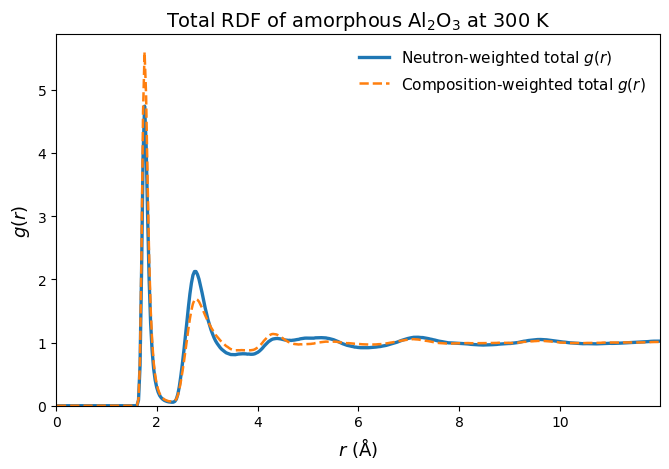

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Load partial RDF data
# (your file is whitespace-separated with a 1-line header)
# columns: r, gAlAl, gAlO, gOO
# =========================
rdf = np.loadtxt("rdf_ensemble_avg.csv", skiprows=1)
r   = rdf[:, 0]
gAA = rdf[:, 1]   # Al–Al
gAO = rdf[:, 2]   # Al–O
gOO = rdf[:, 3]   # O–O

# =========================
# Composition for Al2O3
# =========================
c_Al = 2.0 / 5.0   # 0.4
c_O  = 3.0 / 5.0   # 0.6

# =========================
# Neutron coherent scattering lengths (fm)
# Commonly used values:
#   b(Al) = 3.449 fm
#   b(O)  = 5.803 fm
# (If your target experiment uses isotopic enrichment, update b accordingly.)
# =========================
b_Al = 3.449
b_O  = 5.803

# =========================
# Neutron-weighted total g(r)
# g_n(r) = [sum_{ij} c_i c_j b_i b_j g_ij(r)] / (sum_i c_i b_i)^2
# For binary:
# numerator = cA^2 bA^2 gAA + 2 cA cB bA bB gAB + cB^2 bB^2 gBB
# =========================
den = (c_Al * b_Al + c_O * b_O) ** 2
g_neutron = (c_Al**2 * b_Al**2 * gAA + 2*c_Al*c_O*b_Al*b_O * gAO + c_O**2 * b_O**2 * gOO) / den

# (Optional) also compute composition-weighted total for your own sanity check
g_comp = (c_Al**2 * gAA + 2*c_Al*c_O * gAO + c_O**2 * gOO)

# =========================
# Plot
# =========================
plt.figure(figsize=(6.8, 4.8))

plt.plot(r, g_neutron, lw=2.4, label="Neutron-weighted total $g(r)$")
plt.plot(r, g_comp, lw=1.8, ls="--", label="Composition-weighted total $g(r)$")

plt.xlabel(r"$r$ (Å)", fontsize=13)
plt.ylabel(r"$g(r)$", fontsize=13)
plt.xlim(0, r.max())
plt.ylim(bottom=0)
plt.title("Total RDF of amorphous Al$_2$O$_3$ at 300 K", fontsize=14)
plt.legend(frameon=False, fontsize=11)
plt.tight_layout()

plt.savefig("rdf_total_neutron_weighted_300K.png", dpi=300)
plt.show()


In [5]:
import numpy as np
import glob
from scipy.spatial import cKDTree

# ============================================================
# CN ONLY (Al-centered + O-centered Al–O CN distributions)
# r_cut FIXED from RDF first minimum
# ============================================================

cn_pattern  = "cn_frames_quench_sample*.lammpstrj"

TYPE_AL = 1
TYPE_O  = 2
cn_max = 10

# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
# IMPORTANT: CN cutoff from RDF (Al–O first minimum)
r_cut = 2.325  # Å
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

def iter_lammpstrj(path):
    with open(path) as f:
        while True:
            line = f.readline()
            if not line:
                break
            if not line.startswith("ITEM: TIMESTEP"):
                continue

            f.readline()  # timestep
            f.readline()  # ITEM: NUMBER OF ATOMS
            n = int(f.readline())

            f.readline()  # ITEM: BOX BOUNDS ...
            box = np.array([list(map(float, f.readline().split())) for _ in range(3)])
            L = box[:, 1] - box[:, 0]

            f.readline()  # ITEM: ATOMS ...
            pos = np.zeros((n, 3))
            typ = np.zeros(n, dtype=int)

            for i in range(n):
                parts = f.readline().split()
                typ[i] = int(parts[1])
                pos[i] = [float(parts[2]), float(parts[3]), float(parts[4])]

            yield typ, pos, L


def compute_cn_hist_centered(path, r_cut, center_type, neigh_type):
    hist = np.zeros(cn_max + 1, dtype=float)

    for types, pos, L in iter_lammpstrj(path):
        pos_wrapped = pos % L

        centers = pos_wrapped[types == center_type]
        neighs  = pos_wrapped[types == neigh_type]

        if len(centers) == 0:
            continue

        if len(neighs) == 0:
            cn = np.zeros(len(centers), dtype=int)
        else:
            tree = cKDTree(neighs, boxsize=L)
            cn = np.fromiter(
                (len(lst) for lst in tree.query_ball_point(centers, r_cut)),
                dtype=int,
                count=len(centers)
            )

        cn = np.clip(cn, 0, cn_max)
        hist += np.bincount(cn, minlength=cn_max + 1)

    prob = hist / hist.sum()
    mean_cn = np.sum(np.arange(cn_max + 1) * prob)
    return prob, mean_cn


# ----------------------------
# Load files
# ----------------------------
cn_files = sorted(glob.glob(cn_pattern))
if not cn_files:
    raise FileNotFoundError(f"No CN trajectory files found with pattern: {cn_pattern}")

# ----------------------------
# Compute both distributions
# ----------------------------
probs_Al_center, mean_Al_center = [], []
probs_O_center,  mean_O_center  = [], []

for f in cn_files:
    pA, mA = compute_cn_hist_centered(
        f, r_cut, center_type=TYPE_AL, neigh_type=TYPE_O
    )
    probs_Al_center.append(pA)
    mean_Al_center.append(mA)

    pO, mO = compute_cn_hist_centered(
        f, r_cut, center_type=TYPE_O, neigh_type=TYPE_AL
    )
    probs_O_center.append(pO)
    mean_O_center.append(mO)

probs_Al_center = np.array(probs_Al_center)
probs_O_center  = np.array(probs_O_center)

# mean + SE
Al_mean = probs_Al_center.mean(axis=0)
Al_se   = probs_Al_center.std(axis=0, ddof=1) / np.sqrt(len(probs_Al_center))
O_mean  = probs_O_center.mean(axis=0)
O_se    = probs_O_center.std(axis=0, ddof=1) / np.sqrt(len(probs_O_center))

Al_CN_mean = np.mean(mean_Al_center)
Al_CN_se   = np.std(mean_Al_center, ddof=1) / np.sqrt(len(mean_Al_center))
O_CN_mean  = np.mean(mean_O_center)
O_CN_se    = np.std(mean_O_center, ddof=1) / np.sqrt(len(mean_O_center))

# ----------------------------
# Print results
# ----------------------------
cn_vals = np.arange(cn_max + 1)

print(f"r_cut used (Al–O first minimum) = {r_cut:.3f} Å")

print("\n===== Al-centered Al–O CN (Al counts O) =====")
for cn, pm, pse in zip(cn_vals, Al_mean, Al_se):
    print(f"CN={cn:2d}  prob={pm:.6f}  se={pse:.6f}")
print(f"<CN>_Al-centered = {Al_CN_mean:.4f} ± {Al_CN_se:.4f}\n")

print("===== O-centered Al–O CN (O counts Al) =====")
for cn, pm, pse in zip(cn_vals, O_mean, O_se):
    print(f"CN={cn:2d}  prob={pm:.6f}  se={pse:.6f}")
print(f"<CN>_O-centered = {O_CN_mean:.4f} ± {O_CN_se:.4f}\n")



r_cut used (Al–O first minimum) = 2.325 Å

===== Al-centered Al–O CN (Al counts O) =====
CN= 0  prob=0.000000  se=0.000000
CN= 1  prob=0.000000  se=0.000000
CN= 2  prob=0.000000  se=0.000000
CN= 3  prob=0.000001  se=0.000001
CN= 4  prob=0.656185  se=0.007842
CN= 5  prob=0.282490  se=0.008312
CN= 6  prob=0.061323  se=0.002858
CN= 7  prob=0.000000  se=0.000000
CN= 8  prob=0.000000  se=0.000000
CN= 9  prob=0.000000  se=0.000000
CN=10  prob=0.000000  se=0.000000
<CN>_Al-centered = 4.4051 ± 0.0084

===== O-centered Al–O CN (O counts Al) =====
CN= 0  prob=0.000000  se=0.000000
CN= 1  prob=0.000001  se=0.000001
CN= 2  prob=0.124910  se=0.003359
CN= 3  prob=0.813876  se=0.002683
CN= 4  prob=0.060757  se=0.002663
CN= 5  prob=0.000456  se=0.000144
CN= 6  prob=0.000000  se=0.000000
CN= 7  prob=0.000000  se=0.000000
CN= 8  prob=0.000000  se=0.000000
CN= 9  prob=0.000000  se=0.000000
CN=10  prob=0.000000  se=0.000000
<CN>_O-centered = 2.9368 ± 0.0056

